In [1]:
import os
import xarray as xr
import regionmask
import matplotlib.pyplot as plt
import numpy as np

In [34]:
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"

In [35]:
bmr = xr.open_dataarray(f"{BMR_DIR}GBD_BMR_Country_Mask_COPD_1990-2009.nc")
pop_2050 = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2050.nc4")
o3 = xr.open_dataarray(f"{OSDMA8_DIR}OSDMA8_BC_CESM2_ARISE_01_2035-2069.nc")

In [5]:
pop_lat = pop_2050.lat.values
pop_lon = pop_2050.lon.values

o3_lat = o3.lat.values
o3_lon = o3.lon.values

bmr_lat = bmr.lat.values
bmr_lon = bmr.lon.values

In [6]:
o3_lat_mask = xr.ufuncs.logical_and(o3_lat <= pop_lat.max(), o3_lat >= pop_lat.min())
o3_lon_mask = xr.ufuncs.logical_and(o3_lon <= pop_lon.max(), o3_lon >= pop_lon.min())

bmr_lat_mask = xr.ufuncs.logical_and(bmr_lat <= pop_lat.max(), bmr_lat >= pop_lat.min())
bmr_lon_mask = xr.ufuncs.logical_and(bmr_lon <= pop_lon.max(), bmr_lon >= pop_lon.min())

In [7]:
new_o3 = o3.sel(lat=o3_lat_mask)
new_bmr = bmr.sel(lat=bmr_lat_mask)

In [8]:
o3_interp = new_o3.interp(lat=pop_2050.lat, lon=pop_2050.lon)
bmr_interp = new_bmr.interp(lat=pop_2050.lat, lon=pop_2050.lon)

In [11]:
RR_10ppb = 1.074
# RR = e^(beta*(x-TMREL))
beta = np.log(RR_10ppb)/10
TMREL = 32.4

In [27]:
pop_tot = pop_2050.sum()

In [28]:
pop_weighted_o3 = (pop_2050 * o3_interp)/pop_tot

In [60]:
O3_diff = o3_interp - TMREL
TMREL_O3 = xr.where(O3_diff > 0, O3_diff, 0)

In [68]:
RR = np.exp(beta * TMREL_O3)

In [69]:
AF = (RR - 1)/RR

In [71]:
PAF = (AF * pop_2050)/pop_tot

In [49]:
M = AF * bmr_interp * pop_2050

In [74]:
PM = PAF * bmr_interp * pop_2050

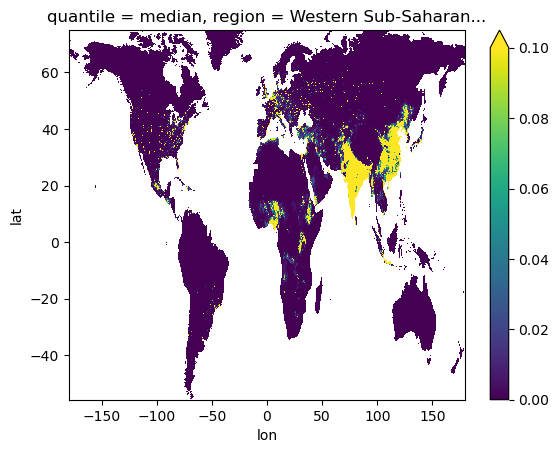

In [86]:
PM.sel(quantile="median", year=slice("2050", "2069")).mean("year").plot(vmax=0.1)

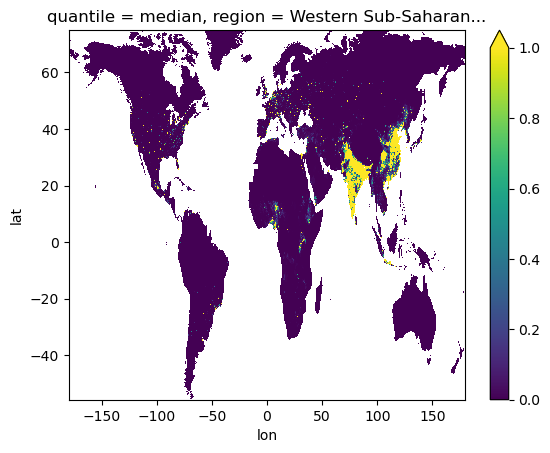

In [82]:
PM.sel(quantile="median", year=slice("2020", "2039")).mean("year").plot(vmax=1)

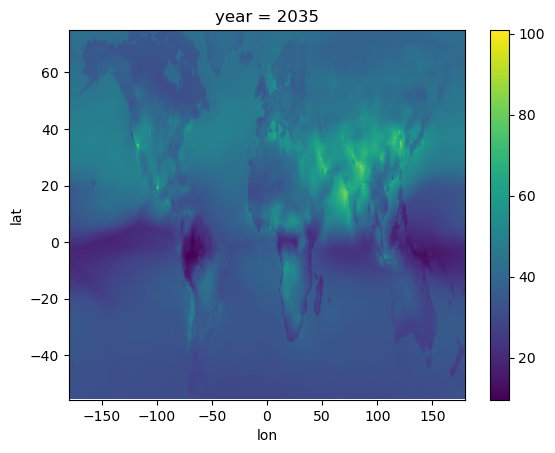

In [84]:
o3_interp[:,:,0].plot()

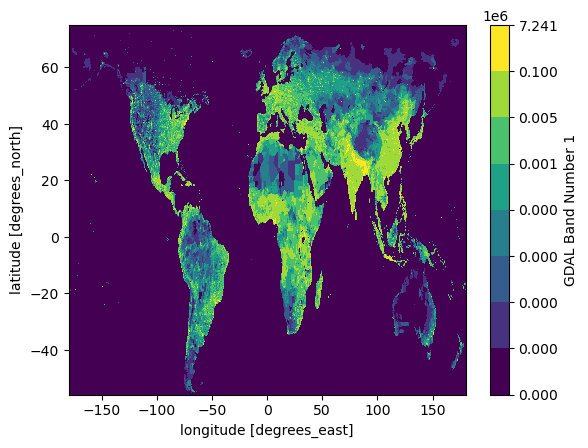

In [54]:
pop_2050.plot(levels=[0, 1, 25, 100, 250, 1000, 5000, 100000, 7241105])

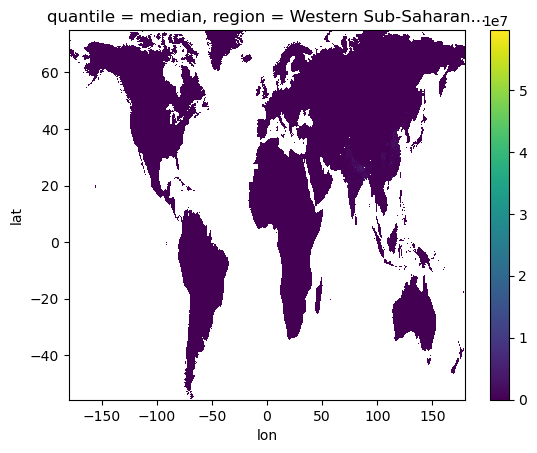

In [40]:
M.sel(quantile="median", year=slice("2020", "2039")).mean("year").plot()

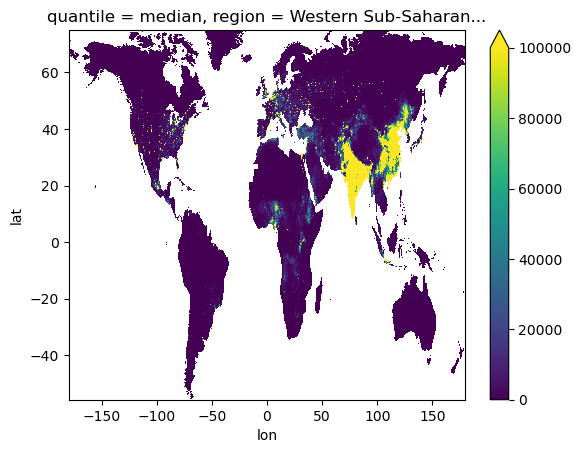

In [21]:
M.sel(quantile="median", year=slice("2050", "2069")).mean("year").plot(vmax=1e5)